In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.metrics import ConfusionMatrixDisplay


In [22]:
df = pd.read_csv(
    "data/diabetes_binary_health_indicators_BRFSS2015.csv"
)
df.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


Sayılar:
Diabetes_binary
0.0    218334
1.0     35346
Name: count, dtype: int64

Oranlar (%):
Diabetes_binary
0.0    86.066698
1.0    13.933302
Name: proportion, dtype: float64


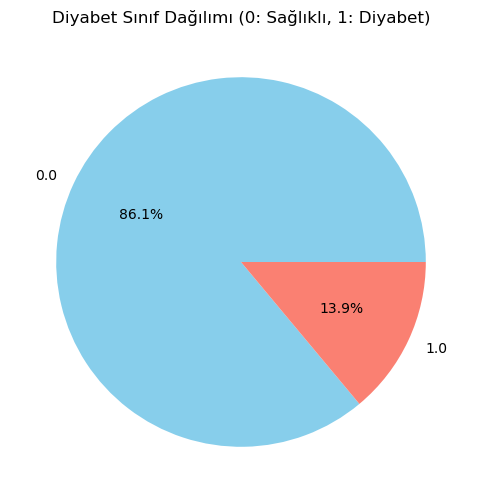

In [3]:
# Sınıf dağılımını sayı ve yüzde olarak göstermek
print("Sayılar:")
print(df["Diabetes_binary"].value_counts())

print("\nOranlar (%):")
print(df["Diabetes_binary"].value_counts(normalize=True) * 100)

# Görsel
plt.figure(figsize=(6, 6))
df["Diabetes_binary"].value_counts().plot.pie(autopct='%1.1f%%', colors=['skyblue', 'salmon'])
plt.title("Diyabet Sınıf Dağılımı (0: Sağlıklı, 1: Diyabet)")
plt.ylabel("") # Yan taraftaki çirkin yazıyı kaldırır
plt.show()

## Sınıf Dengesizliği ve Metrik Seçimi Gerekçesi

Veri setimiz üzerinde yapılan keşifsel analizde (EDA), hedef değişkenin (Diabetes_binary) sınıf dağılımında ciddi bir dengesizlik olduğu tespit edilmiştir. Analiz sonucunda, örneklemin %86.1'inin Sağlıklı (Sınıf 0), sadece %13.9'unun Diyabetli (Sınıf 1) olduğu görülmüştür.

Bu %14'lük azınlık oranı, model değerlendirmesinde neden standart "Doğruluk (Accuracy)" metriğinin yetersiz kaldığının en büyük kanıtıdır. Eğer modelimiz hiçbir şey öğrenmeden herkese "Sağlıklı" tahmini yapsaydı, matematiksel olarak zaten %86.1 Accuracy skoru elde edecekti. Ancak bu durumda tek bir diyabet hastası bile tespit edilemeyecekti (Recall = 0).

Bu yanılgıya düşmemek ve projenin "halk sağlığı" hedefine hizmet etmek amacıyla;

Model başarısı Accuracy yerine, modelin hasta sınıfını ayırt etme gücünü gösteren ROC-AUC skoru ile ölçülmüştür.

Model optimizasyonunda ise, diyabetli bireyleri gözden kaçırmanın maliyeti (False Negative) yüksek olduğu için Recall (Duyarlılık) ve F1-Score metrikleri önceliklendirilmiştir.

# Aykırı Değer Analizi: 

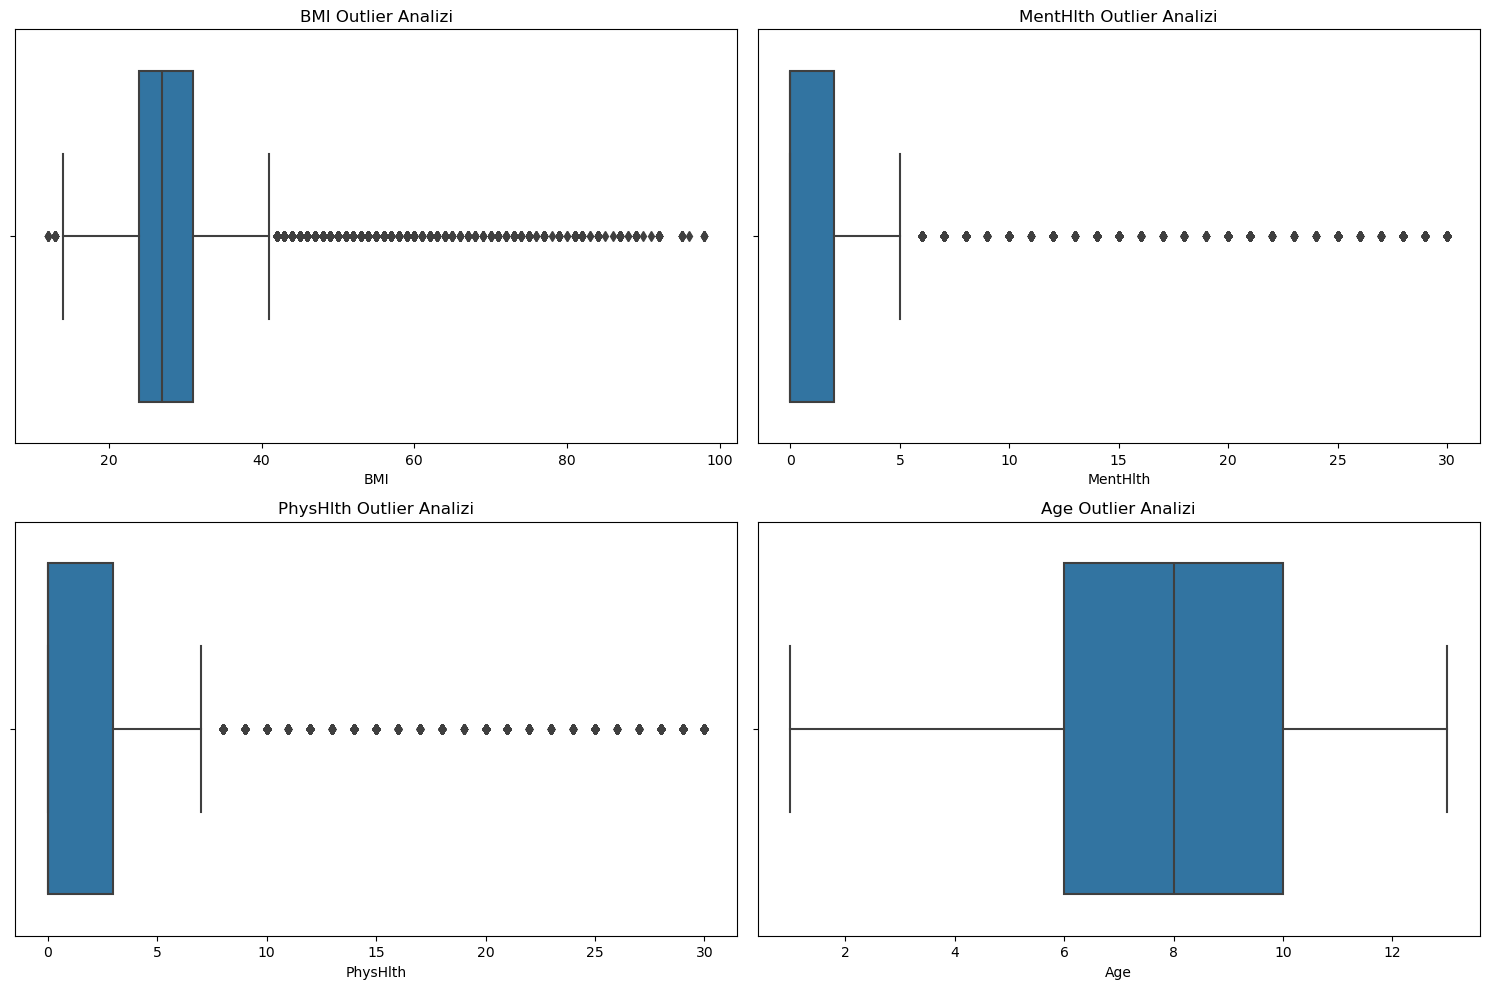

In [4]:
# Veri setindeki aykırı değerleri görmek için boxplot çizimi
plt.figure(figsize=(15, 10))
# Sadece sayısal ve sürekli değişkenleri seçtik
cols_to_check = ['BMI', 'MentHlth', 'PhysHlth', 'Age'] 

for i, col in enumerate(cols_to_check):
    plt.subplot(2, 2, i+1)
    sns.boxplot(x=df[col])
    plt.title(f'{col} Outlier Analizi')
plt.tight_layout()
plt.show()

Veri setindeki sayısal ve sürekli değişkenler (BMI, MentHlth, PhysHlth, Age) üzerinde Boxplot (Kutu Grafiği) yöntemi kullanılarak aykırı değer analizi yapılmıştır. İstatistiksel olarak "outlier" (aykırı) görünen değerler incelenmiş ve bunların hatalı veri (noise) olmadığı, aksine problemin doğası gereği kritik öneme sahip "uç vakalar" olduğu tespit edilmiştir. Değişken bazlı değerlendirmemiz şöyledir:

BMI (Vücut Kitle İndeksi): Grafikte üst çeyreğin üzerinde çok sayıda aykırı değer gözlemlenmiştir. Bu değerler 40, 50 ve üzeri BMI skorlarını temsil etmektedir. Tıbbi literatürde bu değerler "Morbid Obezite" olarak sınıflandırılır. Obezite, Tip 2 diyabetin en güçlü risk faktörlerinden biri olduğu için, bu yüksek değerlerin veri setinden silinmesi, modelin en önemli ayırt edici sinyallerden birini kaybetmesine neden olacaktır.

MentHlth (Ruh Sağlığı) & PhysHlth (Fiziksel Sağlık): Bu değişkenlerde verinin büyük çoğunluğu "0" (sıfır) değerinde toplanmıştır (Zero-inflated data). Bu nedenle, son 30 gün içinde 10, 20 veya 30 gün sorun yaşadığını belirten katılımcılar grafikte aykırı değer gibi görünmektedir. Ancak bu kişiler, kronik fiziksel rahatsızlığı olan veya ciddi depresyon/stres yaşayan bireylerdir. Diyabetli hasta profilini temsil etme ihtimalleri yüksek olduğu için bu değerler korunmuştur.

Age (Yaş): Yaş değişkeni 13 seviyeli bir kategori (18 yaştan 80+ yaşa kadar) olarak kodlanmıştır. Dağılımda görülebilecek uç değerler, yaşlı nüfusu temsil etmektedir. Diyabet prevalansı yaşla birlikte arttığı için, ileri yaş gruplarını temsil eden verilerin korunması model başarısı için kritiktir.

Karar: Bahsi geçen "istatistiksel aykırı değerlerin" hepsi tıbbi açıdan anlamlı ve gerçek hayat verisidir. Modelin diyabetli (Class 1) sınıfını doğru tespit edebilmesi (yüksek Recall) için bu değerlerin silinmemesine ve baskılanmamasına (winsorization yapılmamasına) karar verilmiştir.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_binary       253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  

In [6]:
df.isna().sum()

Diabetes_binary         0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64

Boş veri olmadığı görülmüştür.

In [8]:
X = df.drop("Diabetes_binary", axis=1)
y = df["Diabetes_binary"]

# Korelasyon Analizi

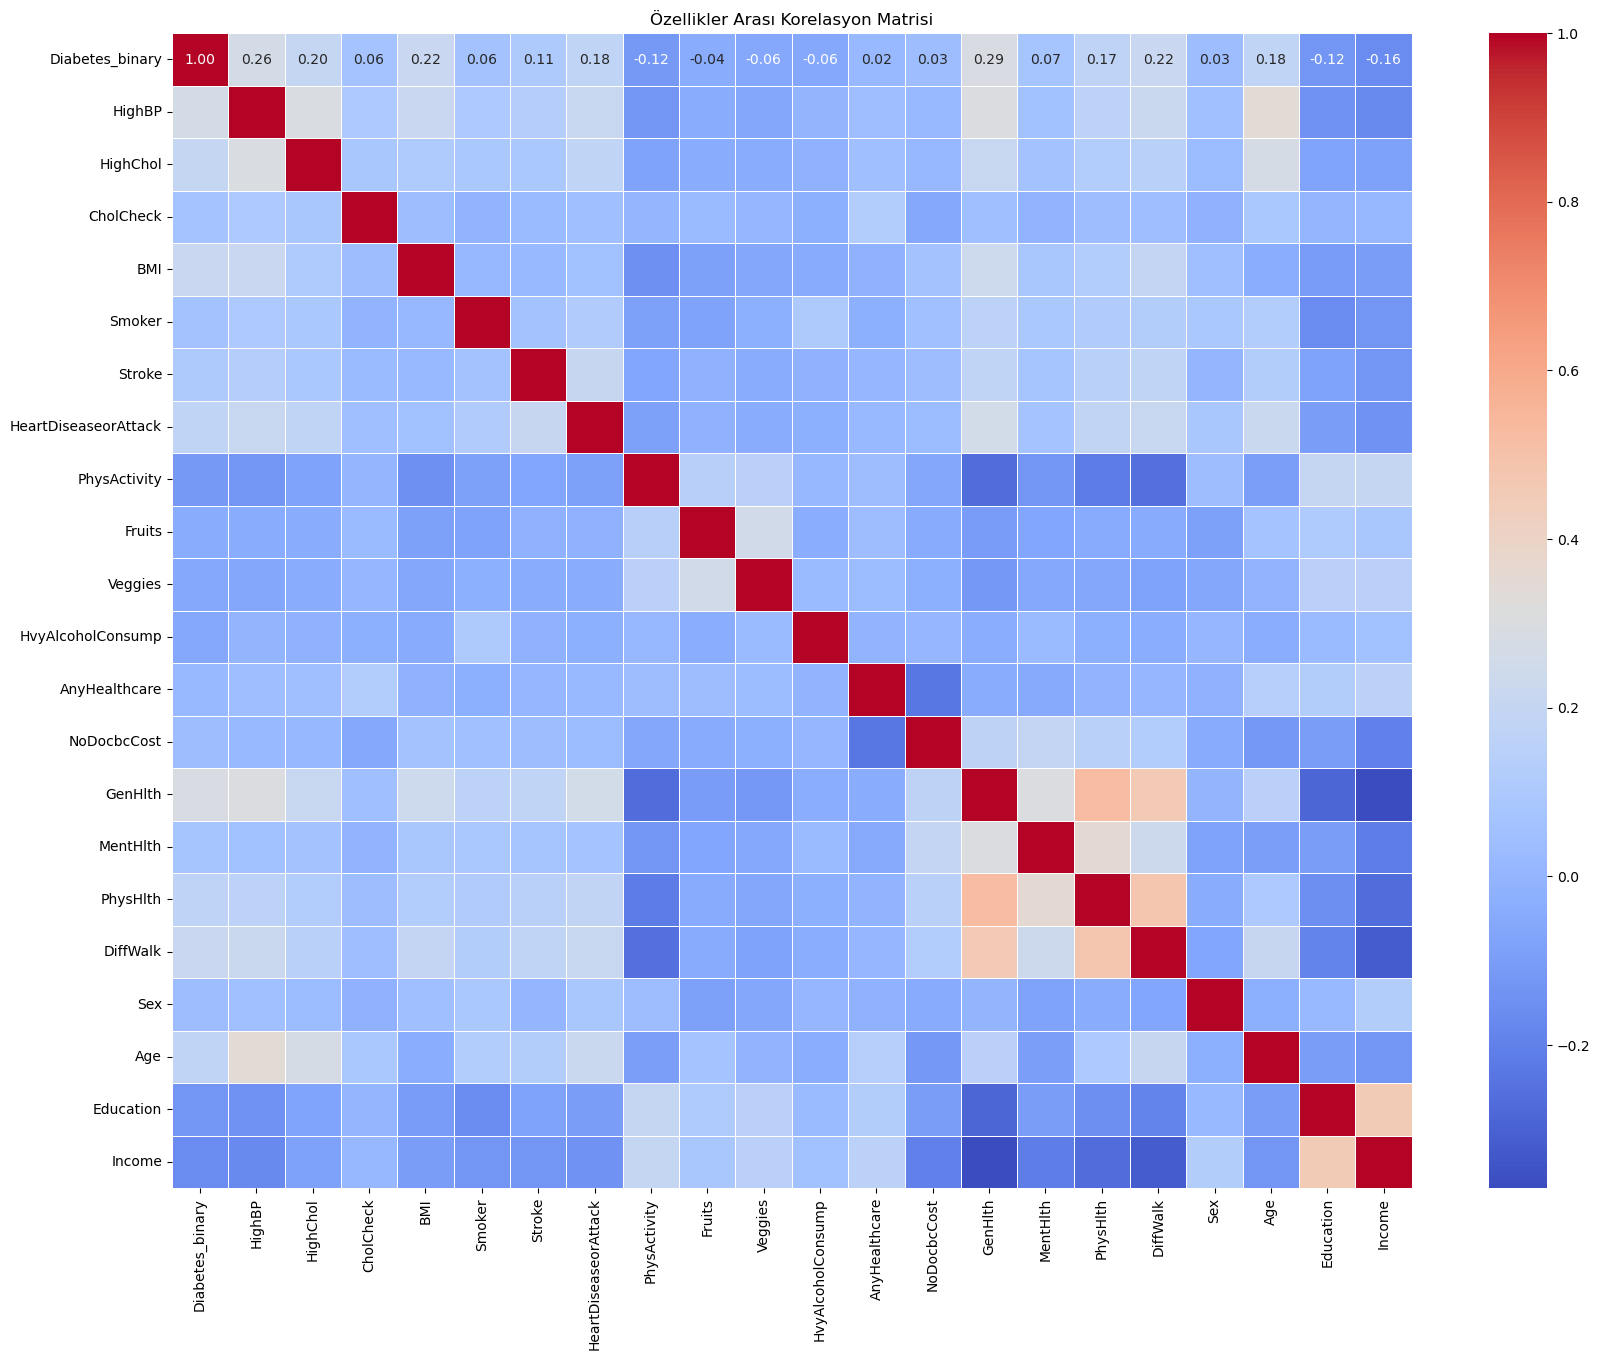

In [9]:
# Korelasyon Matrisi
plt.figure(figsize=(20, 15))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title("Özellikler Arası Korelasyon Matrisi")
plt.show()

### Raporda:
6.2. Korelasyon Analizi ve Özellik İlişkileri

Veri setimizdeki bağımsız değişkenlerin hedef değişken (Diabetes_binary) ile olan ilişkisini ve kendi aralarındaki etkileşimleri incelemek amacıyla Pearson korelasyon katsayısı kullanılarak bir ısı haritası (heatmap) oluşturulmuştur.

Analiz sonuçlarına göre, diyabet teşhisi ile en güçlü pozitif ilişkiye sahip değişkenler sırasıyla Genel Sağlık Durumu (GenHlth: 0.29), Yüksek Tansiyon (HighBP: 0.26) ve Vücut Kitle İndeksi (BMI: 0.22) olarak belirlenmiştir. Ayrıca, yürüme güçlüğü (DiffWalk: 0.22) ve yüksek kolesterol (HighChol: 0.20) de diyabetle belirgin bir ilişki içindedir. Bu bulgular, obezite ve hipertansiyonun diyabet için birincil risk faktörleri olduğunu belirten tıbbi literatür ile tam bir uyum göstermektedir.

Bununla birlikte, Gelir (Income: -0.16) ve Eğitim (Education: -0.12) seviyeleri ile diyabet arasında negatif yönlü bir ilişki gözlemlenmiştir. Bu durum, sosyoekonomik düzeyi yüksek bireylerin sağlık hizmetlerine erişim ve sağlıklı yaşam bilinci konusundaki avantajlarının diyabet riskini düşürdüğü şeklinde yorumlanmıştır. Meyve-sebze tüketimi ve sigara kullanımı gibi değişkenlerin korelasyon katsayılarının düşük çıkması ise, bu faktörlerin etkisiz olduğundan ziyade, BMI gibi daha baskın fizyolojik göstergelerin model için daha ayırt edici olduğunu göstermektedir.

Son olarak, bağımsız değişkenler arası ilişkiler (Multicollinearity) incelendiğinde; GenHlth ile PhysHlth arasında beklenen orta düzeyde bir ilişki görülmesine rağmen, modelin varyansını olumsuz etkileyecek kritik eşik (0.90 üzeri) aşılmamıştır. Bu nedenle, veri setindeki tüm özelliklerin modelleme aşamasında kullanılmasına karar verilmiştir.



In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Veri dengesizliği korunarak (Stratified Sampling) eğitim ve test setlerine ayrılmıştır."

In [11]:
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)

dummy_score = dummy.score(X_test, y_test)
dummy_score

0.8606709239987386

In [12]:
pipe_lr = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=2000,
        class_weight="balanced", # Azınlık sınıfı (Diyabetlileri) yanlış bilirsen sana çok ceza veririm"
        random_state=42
    ))
])

pipe_lr.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=2000,
                                    random_state=42))])

In [13]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

pipe_rf = Pipeline(steps=[
    ("model", RandomForestClassifier(
        n_estimators=600,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced_subsample",
        max_depth=14,
        min_samples_leaf=10,
        min_samples_split=50,
        max_features="sqrt"
    ))
])

pipe_rf.fit(X_train, y_train)

Pipeline(steps=[('model',
                 RandomForestClassifier(class_weight='balanced_subsample',
                                        max_depth=14, min_samples_leaf=10,
                                        min_samples_split=50, n_estimators=600,
                                        n_jobs=-1, random_state=42))])

# Hiperparametre Optimizasyonu" (Hyperparameter Tuning

In [14]:
pipe_gb = Pipeline(steps=[
    ("model", GradientBoostingClassifier(random_state=42))
])

param_grid_gb = {
    "model__n_estimators": [200, 400],
    "model__learning_rate": [0.05, 0.1],
    "model__max_depth": [2, 3],
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

grid_gb = GridSearchCV(
    estimator=pipe_gb,
    param_grid=param_grid_gb,
    scoring="f1",   # Modeller Accuracy yerine, dengesiz verilerde daha güvenilir olan F1-Score metriğini maximize edecek şekilde eğitilmiştir."
    cv=cv,
    verbose=1
)

grid_gb.fit(X_train, y_train)

print("Best params:", grid_gb.best_params_)
print("Best CV score:", grid_gb.best_score_)

best_gb = grid_gb.best_estimator_


Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best params: {'model__learning_rate': 0.1, 'model__max_depth': 2, 'model__n_estimators': 400}
Best CV score: 0.2763081544515148


In [15]:
import numpy as np
from sklearn.metrics import classification_report, roc_auc_score,average_precision_score

def evaluate(pipe, X_test, y_test, name="model", threshold=0.5):
    auc = None
    pr_auc = None
   
    if hasattr(pipe, "predict_proba"):
        y_prob = pipe.predict_proba(X_test)[:, 1]
        y_pred = (y_prob >= threshold).astype(int)
        auc = roc_auc_score(y_test, y_prob)
        pr_auc = average_precision_score(y_test, y_prob)
        print(f"{name} ROC-AUC: {auc:.4f}")
        print(f"{name} PR-AUC : {pr_auc:.4f}")
        print(f"{name} Threshold: {threshold}")
    else:
        y_pred = pipe.predict(X_test)

    ConfusionMatrixDisplay.from_estimator(pipe, X_test, y_test, cmap='Blues')
    plt.title(f"{name} Hata Matrisi")
    plt.show()

    print(f"\n{name} Report:\n{classification_report(y_test, y_pred, digits=4)}")

    labels = list(np.unique(y_test))
    rep = classification_report(y_test, y_pred, labels=labels, output_dict=True, zero_division=0)

    k0, k1 = str(labels[0]), str(labels[1])

    row = {
        "Model": name,
        f"R({labels[1]})": rep[k1]["recall"],
        f"F1({labels[1]})": rep[k1]["f1-score"],
        "ROC-AUC": auc,
        "PR-AUC": pr_auc
    }
    return row

# Logistic Reg.
Logistic Regression (İyi ama Gürültülü): Recall çok yüksek (0.76), yani hastaları çok iyi yakalıyor ama Precision çok düşük (0.31). Çok fazla sağlıklı insana "hastasın" diyor (False Positive çok yüksek).

Logistic Regression ROC-AUC: 0.8196
Logistic Regression PR-AUC : 0.3926
Logistic Regression Threshold: 0.5


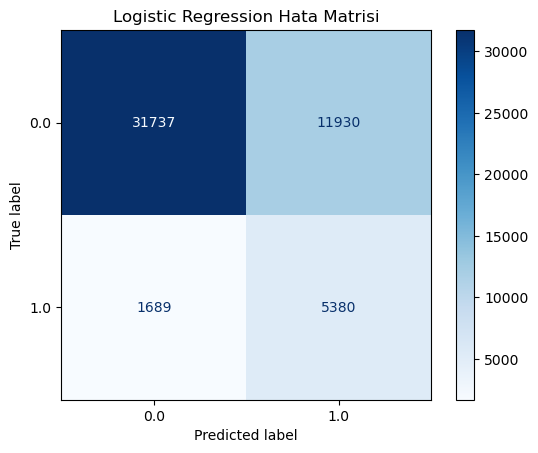


Logistic Regression Report:
              precision    recall  f1-score   support

         0.0     0.9495    0.7268    0.8233     43667
         1.0     0.3108    0.7611    0.4414      7069

    accuracy                         0.7316     50736
   macro avg     0.6301    0.7439    0.6324     50736
weighted avg     0.8605    0.7316    0.7701     50736



In [16]:
results = []


results.append(evaluate(pipe_lr, X_test, y_test, name="Logistic Regression", threshold=0.5))


# Random For.
(Başarısız): Class 1 Recall oranı 0.15. Yani 100 hastanın 85'ini kaçırmış. Sadece sağlıklıları bilerek Accuracy kasmış. Bu model tıbbi açıdan kullanılamaz

Random Forest ROC-AUC: 0.8248
Random Forest PR-AUC : 0.4190
Random Forest Threshold: 0.5


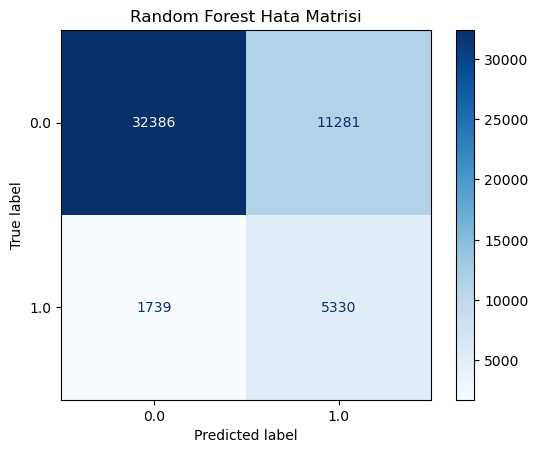


Random Forest Report:
              precision    recall  f1-score   support

         0.0     0.9490    0.7417    0.8326     43667
         1.0     0.3209    0.7540    0.4502      7069

    accuracy                         0.7434     50736
   macro avg     0.6350    0.7478    0.6414     50736
weighted avg     0.8615    0.7434    0.7793     50736



In [17]:
results.append(evaluate(pipe_rf, X_test, y_test, name="Random Forest"))


Gradient Boosting ROC-AUC: 0.8269
Gradient Boosting PR-AUC : 0.4230
Gradient Boosting Threshold: 0.1


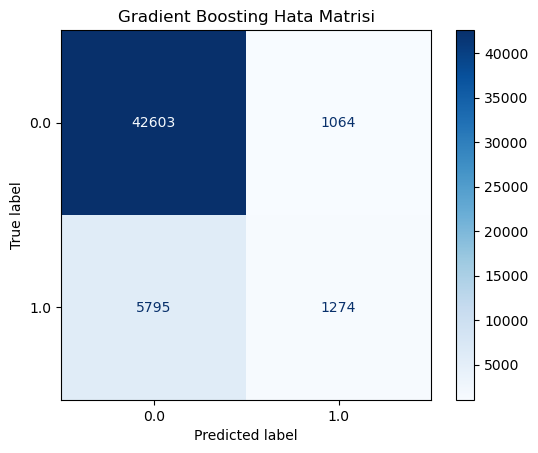


Gradient Boosting Report:
              precision    recall  f1-score   support

         0.0     0.9648    0.6361    0.7667     43667
         1.0     0.2759    0.8567    0.4174      7069

    accuracy                         0.6668     50736
   macro avg     0.6204    0.7464    0.5921     50736
weighted avg     0.8688    0.6668    0.7180     50736



In [18]:
results.append(evaluate(best_gb, X_test, y_test, "Gradient Boosting",threshold=0.1))

In [19]:
df = pd.DataFrame(results).round(4)
df

,Model,R(1.0),F1(1.0),ROC-AUC,PR-AUC
0,Logistic Regression,0.7611,0.4414,0.8196,0.3926
1,Random Forest,0.7540,0.4502,0.8248,0.4190
2,Gradient Boosting,0.8567,0.4174,0.8269,0.4230


<Figure size 1000x800 with 0 Axes>

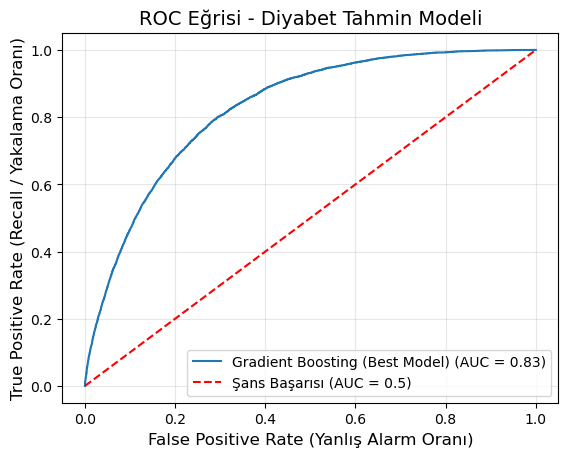

In [20]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

# Grafik boyutu ayarlama
plt.figure(figsize=(10, 8))

# Gradient Boosting Modeli (best_gb) için eğriyi çizdirme
# best_gb: GridSearchCV sonucunda elde edilen en iyi modeldir.
RocCurveDisplay.from_estimator(
    best_gb, 
    X_test, 
    y_test, 
    name="Gradient Boosting (Best Model)"
)

# Şans çizgisini ekleme (Mükemmel köşegen)
plt.plot([0, 1], [0, 1], "r--", label="Şans Başarısı (AUC = 0.5)")

# Başlık ve etiketler
plt.title("ROC Eğrisi - Diyabet Tahmin Modeli", fontsize=14)
plt.xlabel("False Positive Rate (Yanlış Alarm Oranı)", fontsize=12)
plt.ylabel("True Positive Rate (Recall / Yakalama Oranı)", fontsize=12)
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.show()

Modelimiz 0.83 seviyesindeki AUC değeri (Eğri Altında Kalan Alan) ile rastgele tahminin (kırmızı çizgi) çok üzerinde bir performans sergilemiştir. Eğrinin sol üst köşeye yaklaşması, modelin yanlış alarm oranını artırmadan hastaları tespit etme yeteneğinin yüksek olduğunu göstermektedir."